# Linear Regression & Gradient Descent 
Exploring the mathematical foundations of linear regression, implementing gradient descent in NumPy, and benchmarking against scikit-learn

Dataset: Car Data.csv

In [140]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")  # suppress sklearn convergence warnings for cleaner output

## 1. The Data

The Car Data dataset contains 301 used car listings with features including 
present price, kilometres driven, fuel type, and year. The target variable is 
**Selling_Price** — what the car actually sold for. The goal is to predict 
resale value from these features.

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Text(0, 0.5, 'Mileage (Km)')

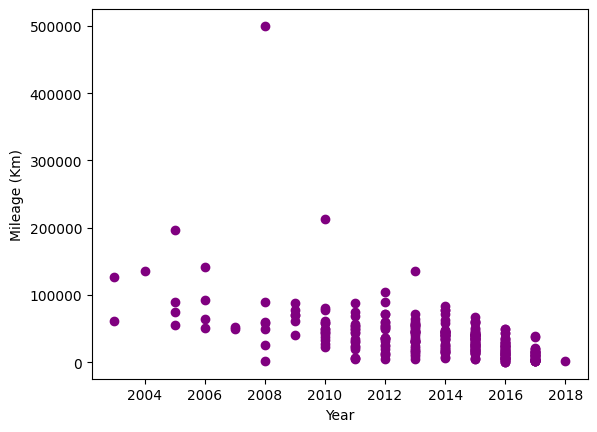

In [141]:
vehicle_data = pd.read_csv(r"C:\Users\Rebecca\Desktop\Python Projects\GitHub - Vehicle Data\car data.csv")
display(vehicle_data.head())

plt.scatter(vehicle_data['Year'], vehicle_data['Kms_Driven'], color='purple')
plt.xlabel('Year')
plt.ylabel('Mileage (Km)')

## 2. The Theory
The hypothesis: ŷ = θ₀ + θ₁x <br>
Cost function (MSE): J(θ) = (1/2m) Σ(ŷ - y)² <br>
Gradient update: θ := θ - α · ∂J/∂θ <br>

Model beta:  -7051.580967568475
Model intercept:  14236207.43058202
R^2 score:  0.2749345756409639
RMSE:  33057.432567821576


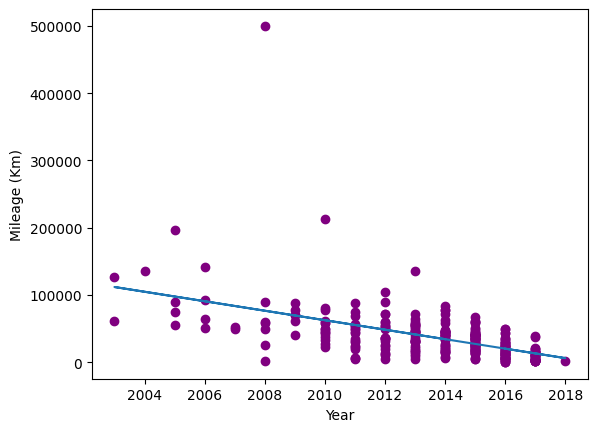

In [142]:
X = vehicle_data[['Year']].values.reshape(-1,1)
y = vehicle_data[['Kms_Driven']]
model = LinearRegression()
model.fit(X,y)

predicted = [model.predict([[vehicle_data['Year'][i]]])[0][0] for i in range(len(vehicle_data))]
years = [vehicle_data['Year'][i] for i in range (0, len(vehicle_data['Year']))]
prediction_data = pd.DataFrame({'Year':years, 'Predicted Values':predicted})
plt.plot(prediction_data['Year'], prediction_data['Predicted Values'])
plt.scatter(vehicle_data['Year'], vehicle_data['Kms_Driven'], color='purple')
plt.xlabel('Year')
plt.ylabel('Mileage (Km)')

#Inspecting the model 
print("Model beta: ", model.coef_[0][0])
print("Model intercept: ", model.intercept_[0])
print("R^2 score: ", r2_score(y, model.predict(X)))
print("RMSE: ", np.sqrt(mean_squared_error(y, model.predict(X))))

The main issue from this model arise in how the data is set up: <br>
Having an intercept of 14,000,000 Km is unrealistic, since no car has that much mileage before being written off, but not only this, in the year 0,
there were no cars! The way this model should be improved is looking at data from when cars were first made (or just after), I reckon this would
show a non-linear relationship. However for the data we have, I think it is safe to assume linearity for this time period. Extrapolation would not 
be suitable for this model. <br>
<br>
These cars would have been sampled in 2018 when the new cars were made, if we were to extrapolate to 2020, we would expect the car to be at low mileage
However this model would no long stand since the 2018 cars would have aged, we could predict how they age, but it means that particularly this data
is not suitable for modelling future predictions, and also only for model short term backwards-interpolation


So how did this work? <br>
We have X our data, which I had simply modelled as the year, however we can have multiple dimensions of X if we wanted, all important factors of the mileage we may predict in our car, the more beta parameters we have, only if the are no-redundant, the more accurate our model may be for predicting mileage. Other important factors may include; <br>
1. Type of engine
2. Model of car
3. Transmission
4. Fuel type <br>

just from this dataset, however if we had the category of insurance, such as if it has had a write off, or broken down, or incidents relating to the function of the car, this may also affect it. <br>

So we have X, our year, and we have $y$ our observations of mileage, but we do not have $\beta$, which is what we are predicting. <br>
So we use the linear regression model, which uses the normal equation: <br>
$ J(\beta) = 1/n \sum_{i=1}^n (y_i - \hat{y}_i)^2 $ <br>
Which we can minimise to find $\beta$, or in algebraic terms, we write: <br>
$ \beta = (X^{T}X)^{-1}X^{T}y $ <br>
or in contextual terms: <br>
$ \beta = (Year^{T}Year)^{-1}Year^{T}Mileage_{observed} $ <br>
Which $Year^T$ is the same as writing Year as a row vector, and in an unsolved form: <br>
$Mileage_{observed} = \beta *Year + \epsilon$

## Multivariable predictor 

301


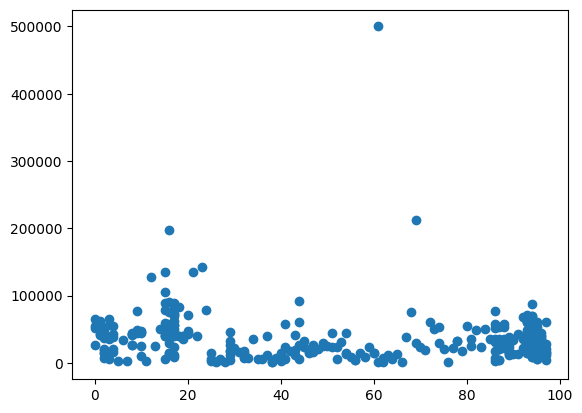

In [143]:
#Using more than one beta parameter
#Since the rest of the parameters are categorical, we need to create new columns to fit them to the model 
vehicle_data['Car_Name_Key'] = pd.factorize(vehicle_data['Car_Name'])[0]
vehicle_data['Transmission_Key'] = pd.factorize(vehicle_data['Transmission'])[0]
vehicle_data['Fuel_Type_Key'] = pd.factorize(vehicle_data['Fuel_Type'])[0]
vehicle_data['Seller_Type_Key'] = pd.factorize(vehicle_data['Seller_Type'])[0]
vehicle_data
print(len(vehicle_data))
#Plotting to see if any have correlation
plt.scatter(vehicle_data['Car_Name_Key'], vehicle_data['Kms_Driven'])

In [144]:
cleaned_vehicle_data = vehicle_data[vehicle_data['Kms_Driven']<180000]
X_2 = cleaned_vehicle_data[['Year', 'Transmission_Key', 'Fuel_Type_Key', 'Seller_Type_Key']]
y_2 = cleaned_vehicle_data[['Kms_Driven']]

model_2 = LinearRegression()
model_2.fit(X_2, y_2)
model_2.predict(X_2)

#Inspecting the model 
print("Model beta: ", model_2.coef_[0][0])
print("Model intercept: ", model_2.intercept_[0])
print("R^2 score: ", r2_score(y_2, model_2.predict(X_2)))
print("RMSE: ", np.sqrt(mean_squared_error(y_2, model_2.predict(X_2))))

Model beta:  -5657.645430761
Model intercept:  11426817.440059518
R^2 score:  0.534385816385627
RMSE:  16790.199366794124


Thus our second model with more beta, has a higher R^2 score, which means it is more closely fit to our model, it explains 34% of the variance, rather
than 27%, in addition our RMSE is lower which we ideally want, the data has a lot of variation, so I would not expect this to be lower than 2000

In [145]:
#A better way to predict data is through testing and training, so lets split our data a bit better
X_train, X_test, y_train, y_test = train_test_split(X_2, y_2, test_size=0.2)
model_2.fit(X_train, y_train)
model_2.predict(X_test)
#And now we can get a better look into the R score and the RMSE 
print("Model beta: ", model_2.coef_[0][0])
print("Model intercept: ", model_2.intercept_[0])
print("R^2 score: ", r2_score(y_test, model_2.predict(X_test)))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, model_2.predict(X_test)))) 

Model beta:  -5938.270315929842
Model intercept:  11992487.679514049
R^2 score:  0.5148864936016717
RMSE:  18035.61883186113


The RMSE is actually a lot lower which is strange but good!
The reason the RMSE is lower, may be because we picked up outliers in our training sample not the testing sample, if we were to do this in real life,
we would exclude outliers from this investigation, of course there are outliers which are real-world existences, but they are UNLIKELY, and that
is the main point, we cannot predict properly with unlikely situations!

### Validation of Modelling

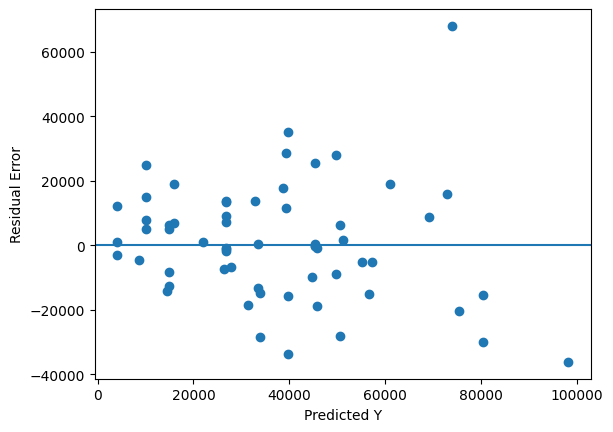

In [146]:
#Lets validate the model by running diagnostics
#Residual analysis
residuals = y_test - model_2.predict(X_test)
plt.scatter(model_2.predict(X_test), residuals)
plt.axhline(0)
plt.xlabel('Predicted Y')
plt.ylabel('Residual Error')
plt.show()


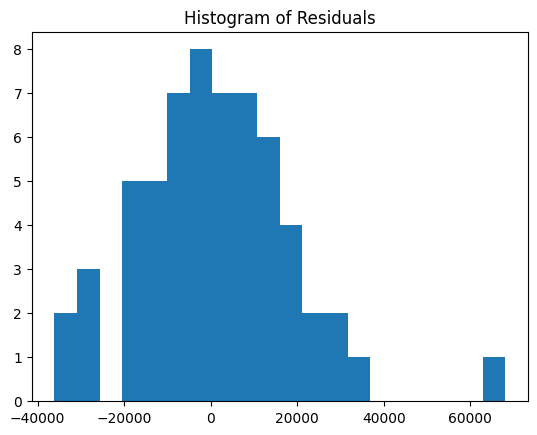

In [147]:
plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")
plt.show()
#I am happy in saying this data is roughly normally distributed, we do not expect a perfect distribution in real world data

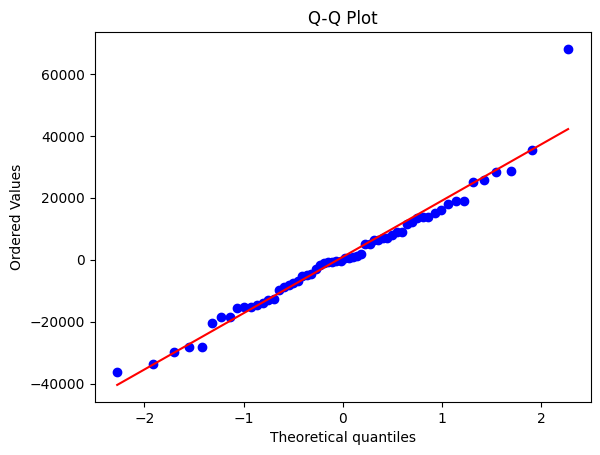

In [148]:
import scipy.stats as stats
stats.probplot(np.asarray(residuals).flatten(), dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()
#The QQ-plot is fairly consistent, showing us a normal distrbution is a good fit for the residual data

The residual plot shows no clear pattern, suggesting the linearity assumption is reasonable. The spread of residuals appears approximately constant, indicating homoscedasticity. The histogram and Q-Q plot suggest residuals are approximately normally distributed, supporting the validity of the model assumptions.

## Ridge and Lasso Regression (Regularisation)

Ridge Regression (L2 Regularisation) includes a penalty, so the model is forced to keep coefficients small and smooth, by optimising the equation: <br>
$Loss = SSE + \lambda \sum_j \beta_j^2$ <br>
Lasso Regression (L1 Regularisation) includes an absolute value, which basically gets rid of redundant coefficients: <br>
$Loss = SSE + \lambda \sum_j |\beta_j|$ <br>
In our code, $\alpha$ represents $\lambda$ in the the equation, now picking a small  $\alpha$ will cause low bias but high variance which is an overfitting risk, a larger $\alpha$ creates a higher bias but lower variance so a simpler model

In [149]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=0.01)
ridge.fit(X_train_scaled, y_train)
print(f"Ridge Alpha {0.01}, R²:", r2_score(y_test, ridge.predict(X_test_scaled)))

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
print(f"Lasso Alpha {0.01}, R²:", r2_score(y_test, lasso.predict(X_test_scaled)))

Ridge Alpha 0.01, R²: 0.5148934629030855
Lasso Alpha 0.01, R²: 0.5148864991612246


In [150]:
print("Ridge Alpha 0.01, RMSE", np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_scaled))))
print("Lasso Alpha 0.01, RMSE", np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_scaled))))

Ridge Alpha 0.01, RMSE 18035.48927855699
Lasso Alpha 0.01, RMSE 18035.618728514204


Ridge and Lasso regression reduce coefficient magnitudes compared to ordinary least squares, helping to stabilise the model and reduce overfitting. While Ridge retains all variables, Lasso can perform feature selection, although in this case no coefficients were reduced to zero

In [151]:
#Now, we are going to look into a cross-validation model which will help us find the best alpha to use, to prevent overfitting
#Ridge CV
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
# Best alpha
print("Best Ridge alpha:", ridge_cv.alpha_)
# Predictions
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
# Evaluation
rmse_ridge_cv = np.sqrt(mean_squared_error(y_test, y_pred_ridge_cv))
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
print("Ridge CV RMSE:", rmse_ridge_cv)
print("Ridge CV R²:", r2_ridge_cv)

Best Ridge alpha: 15.199110829529332
Ridge CV RMSE: 17898.13027391312
Ridge CV R²: 0.5222545061667977


In [152]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
# Best alpha
print("Best Lasso alpha:", lasso_cv.alpha_)
# Predictions
y_pred_lasso_cv = lasso_cv.predict(X_test_scaled)
# Evaluation
rmse_lasso_cv = np.sqrt(mean_squared_error(y_test, y_pred_lasso_cv))
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
print("Lasso CV RMSE:", rmse_lasso_cv)
print("Lasso CV R²:", r2_lasso_cv)

Best Lasso alpha: 657.9332246575682
Lasso CV RMSE: 18084.1459696395
Lasso CV R²: 0.5122724618408203


In [153]:
model_2 = LinearRegression().fit(X_train_scaled, y_train)
# Predictions
y_pred_linear_cv = model_2.predict(X_test_scaled)
# Evaluation
rmse_linear_cv = np.sqrt(mean_squared_error(y_test, y_pred_linear_cv))
r2_linear_cv = r2_score(y_test, y_pred_linear_cv)
print("Linear CV RMSE:", rmse_linear_cv)
print("Linear CV R²:", r2_linear_cv)

Linear CV RMSE: 18035.61883186126
Linear CV R²: 0.5148864936016648


In [154]:
print("Linear coefficients:", model_2.coef_)
print("Ridge CV coefficients:", ridge_cv.coef_)
print("Lasso CV coefficients:", lasso_cv.coef_)

Linear coefficients: [[-15935.28586814   1474.33258327   5341.70664383  -5167.60837928]]
Ridge CV coefficients: [-14946.65139161   1392.31072592   5060.51450986  -4904.0971771 ]
Lasso CV coefficients: [-15193.48450389    881.52248411   4870.99021151  -4688.97081846]


Cross-validation was used to select the optimal regularisation parameter α for Ridge and Lasso regression. This improves robustness by evaluating model performance across multiple folds of the training data rather than relying on a single split. The selected α balances model fit with coefficient shrinkage, helping reduce overfitting. Linear regression was used as a baseline model, while Ridge and Lasso regression were applied to address potential overfitting and multicollinearity. Lasso additionally enabled feature selection, providing a more interpretable mode

### Intuition of using each model: <br>
Situation - Small, clean dataset <br>
    - Linear <br>
Situation - Correlated predictors<br>
    - Ridge <br>
Situation - Too many features <br>
    - Lasso <br>
Situation - Interpretability + selection<br>
    - Lasso <br>
Situation - Stability but keep features <br>
    - Ridge <br>


Comparing Linear, Lasso and Ridge regression, Linear ~ Lasso and Ridge is ever so slightly worse, this means our data most likely does not have correlated predictors, thus minimal stability is required. Lasso provides us with interpretability.

Using linear regression in this dataset provides limitations and benefits, the benefits being the ability to interpolate over this data range, 
however drawbacks come from extrapolation, I would not recommend extrapolating more than a couple of years out of this data range

# Gradient Descent

Gradient Descent is the iterative process of optimising the cost function, this can be modelled through the equation: <br>
$ J(m,b) = 1/n \sum_{i=1}^n (y_i - (mx_i + b))^2 $ <br>
$ m := m - \alpha (\partial J / \partial m)$ <br>
$ b := b - \alpha (\partial J / \partial b)$ <br>

Gradient Descent slope: 2.096864320787731
Gradient Descent intercept: 0.650277795836524


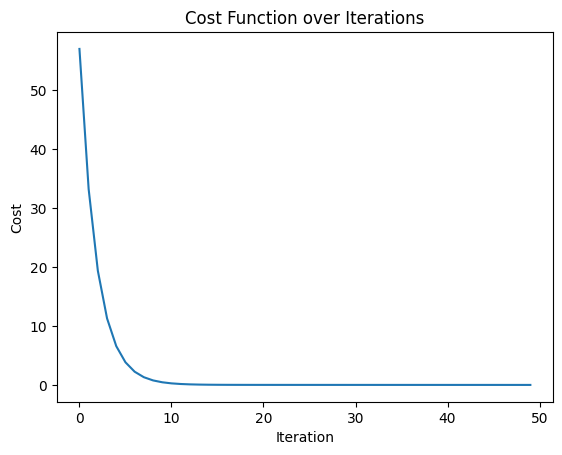

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example data
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 5, 7, 9, 11], dtype=float)   # y = 2x + 1

# Initialise parameters
m = 0
b = 0

# Hyperparameters
alpha = 0.01
iterations = 50
n = len(X)

cost_history = []

# Gradient descent loop
for i in range(iterations):
    y_pred = m * X + b
    
    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    m = m - alpha * dm
    b = b - alpha * db
    
    cost = (1/n) * np.sum((y - y_pred)**2)
    cost_history.append(cost)

print("Gradient Descent slope:", m)
print("Gradient Descent intercept:", b)

# Plot cost over iterations
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function over Iterations")
plt.show()

In [156]:
#Validate with SKLearn Linear Regression
X_sklearn = X.reshape(-1, 1)

model = LinearRegression()
model.fit(X_sklearn, y)

print("Sklearn slope:", model.coef_[0])
print("Sklearn intercept:", model.intercept_)

Sklearn slope: 2.0
Sklearn intercept: 1.0


Applying our gradient descent to previous model, this means upgrading the model to deal with a multivariate X

In [157]:
# Convert to numpy
X = X_train_scaled
y = y_train.to_numpy(dtype=float).reshape(-1, 1)

m, n = X.shape

# Add bias column (for intercept)
X = np.hstack((np.ones((m, 1)), X))   # shape becomes (m, n+1)

# Initialize parameters (including intercept)
theta = np.zeros((n + 1, 1))

alpha = 0.001
iterations = 1000

for i in range(iterations):
    y_pred = X @ theta                # (m,1)
    error = y_pred - y               # (m,1)
    
    gradient = (1/m) * (X.T @ error) # (n+1,1)
    theta = theta - alpha * gradient

,alpha,iterations_to_converge,converged
0,0.01,617,True
1,0.10,62,True
2,1.00,568,False
3,5.00,133,False
4,50.00,69,False
5,100.00,60,False


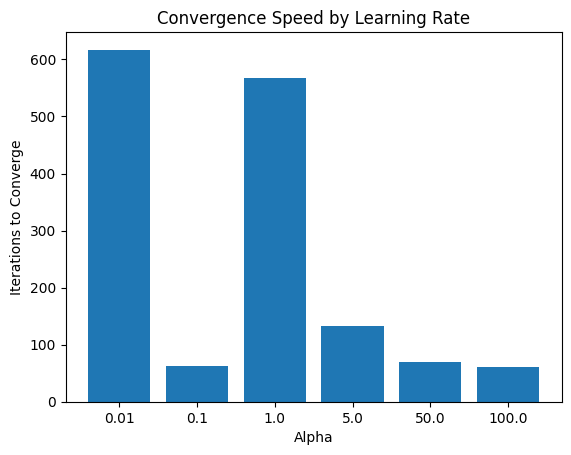

In [158]:
#After how many iterations does each alpha converge?
convergence_results = []
alphas = [0.01, 0.1, 1.0, 5.0, 50, 100]
tolerance = 1e-3
max_iterations = 1000

# Make sure X and y are NumPy arrays
X = np.array(X_train_scaled, dtype=float)
y = np.array(y_train, dtype=float)

# If y is shape (n,1), flatten it to (n,)
if y.ndim > 1:
    y = y.ravel()

n_samples, n_features = X.shape

for alpha in alphas:
    
    w = np.zeros(n_features)   # coefficients for each feature
    b = 0.0                    # intercept
    prev_cost = float('inf')
    
    for i in range(max_iterations):
        
        # Predictions
        y_pred = X @ w + b   # shape: (n_samples,)
        
        # Errors
        error = y - y_pred
        
        # Gradients
        dw = (-2 / n_samples) * (X.T @ error)   # shape: (n_features,)
        db = (-2 / n_samples) * np.sum(error)
        
        # Parameter update
        w -= alpha * dw
        b -= alpha * db
        
        # New predictions after update
        y_pred = X @ w + b
        cost = (1 / n_samples) * np.sum((y - y_pred) ** 2)
        
        # Convergence check
        if abs(prev_cost - cost) < tolerance:
            convergence_results.append({
                "alpha": alpha,
                "iterations_to_converge": i,
                "converged": True
            })
            break
        
        # Stop if things blow up
        if np.isnan(cost) or np.isinf(cost):
            convergence_results.append({
                "alpha": alpha,
                "iterations_to_converge": i,
                "converged": False
            })
            break
        
        prev_cost = cost
    
    else:
        convergence_results.append({
            "alpha": alpha,
            "iterations_to_converge": max_iterations,
            "converged": False
        })

df_conv = pd.DataFrame(convergence_results)
display(df_conv)

plt.bar(df_conv["alpha"].astype(str), df_conv["iterations_to_converge"])
plt.xlabel("Alpha")
plt.ylabel("Iterations to Converge")
plt.title("Convergence Speed by Learning Rate")
plt.show()

Best alpha: 0.6210169418915616


,alpha,converged,stable,iterations,final_cost,monotonicity_ratio
0,0.000001,False,True,5000,1.670450e+09,1.000000
1,0.000002,False,True,5000,1.649776e+09,1.000000
2,0.000003,False,True,5000,1.614467e+09,1.000000
3,0.000005,False,True,5000,1.555066e+09,1.000000
4,0.000009,False,True,5000,1.457745e+09,1.000000
5,0.000016,False,True,5000,1.305446e+09,1.000000
6,0.000028,False,True,5000,1.085320e+09,1.000000
7,0.000049,False,True,5000,8.079008e+08,1.000000
8,0.000085,False,True,5000,5.313052e+08,1.000000
9,0.000149,False,True,5000,3.455986e+08,1.000000


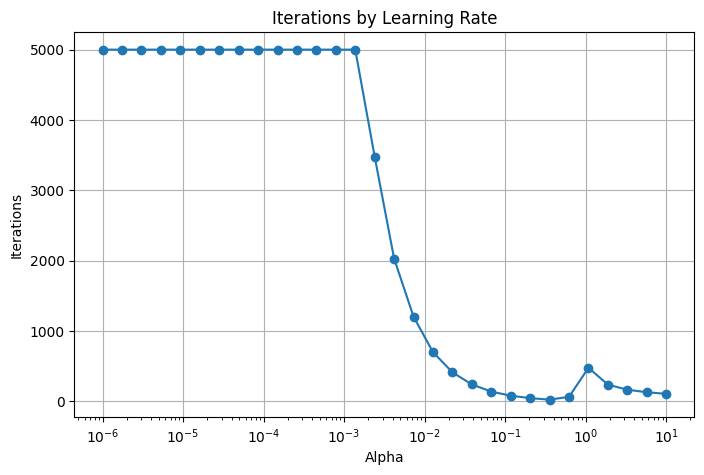

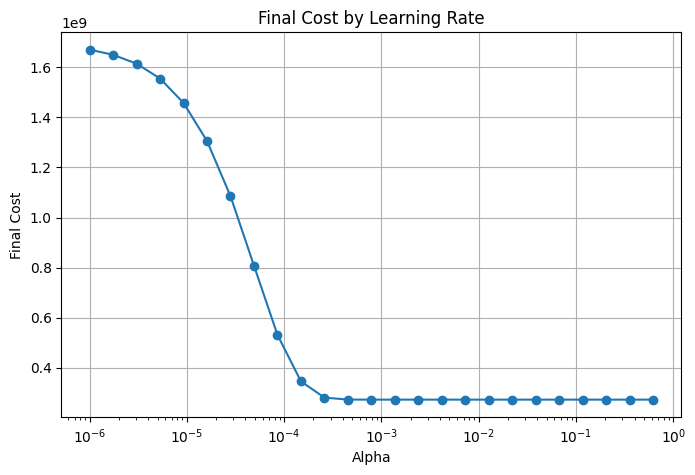

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- make sure X and y are numpy arrays ---
X = np.array(X_train_scaled, dtype=float)
y = np.array(y_train, dtype=float)

# flatten y if needed
if y.ndim > 1:
    y = y.ravel()

n_samples, n_features = X.shape

# --- optional but strongly recommended: scale X ---
# comment this out if you've already scaled your data
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # avoid division by zero
X_scaled = (X - X_mean) / X_std

# --- alpha search space ---
alphas = np.logspace(-6, 1, 30)   # 30 alphas from 10^-6 to 10^1
tolerance = 1e-8
max_iterations = 5000

results = []

for alpha in alphas:
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []
    converged = False
    stable = True

    for i in range(max_iterations):
        # predictions
        y_pred = X_scaled @ w + b
        error = y - y_pred

        # cost
        cost = (1 / n_samples) * np.sum(error ** 2)
        cost_history.append(cost)

        # stop if cost becomes invalid
        if np.isnan(cost) or np.isinf(cost):
            stable = False
            break

        # gradients
        dw = (-2 / n_samples) * (X_scaled.T @ error)
        db = (-2 / n_samples) * np.sum(error)

        # update parameters
        w -= alpha * dw
        b -= alpha * db

        # convergence check
        if i > 0 and abs(cost_history[-2] - cost_history[-1]) < tolerance:
            converged = True
            break

    # diagnose whether cost mostly decreased
    if len(cost_history) > 1:
        num_increases = np.sum(np.diff(cost_history) > 0)
        monotonicity_ratio = 1 - (num_increases / (len(cost_history) - 1))
    else:
        monotonicity_ratio = np.nan

    final_cost = cost_history[-1] if len(cost_history) > 0 else np.inf

    results.append({
        "alpha": alpha,
        "converged": converged,
        "stable": stable,
        "iterations": i + 1,
        "final_cost": final_cost,
        "monotonicity_ratio": monotonicity_ratio
    })

# put results into dataframe
df_results = pd.DataFrame(results)

# keep only good candidates
good_alphas = df_results[
    (df_results["converged"] == True) &
    (df_results["stable"] == True)
].copy()

# choose best alpha:
# 1. lowest final cost
# 2. if tied, fewer iterations
if not good_alphas.empty:
    good_alphas = good_alphas.sort_values(
        by=["final_cost", "iterations"],
        ascending=[True, True]
    )
    best_alpha = good_alphas.iloc[0]["alpha"]
else:
    best_alpha = None

print("Best alpha:", best_alpha)
display(df_results)

# --- plot 1: iterations to convergence ---
plt.figure(figsize=(8, 5))
plt.semilogx(df_results["alpha"], df_results["iterations"], marker='o')
plt.xlabel("Alpha")
plt.ylabel("Iterations")
plt.title("Iterations by Learning Rate")
plt.grid(True)
plt.show()

# --- plot 2: final cost ---
plt.figure(figsize=(8, 5))
plt.semilogx(df_results["alpha"], df_results["final_cost"], marker='o')
plt.xlabel("Alpha")
plt.ylabel("Final Cost")
plt.title("Final Cost by Learning Rate")
plt.grid(True)
plt.show()

Through gradient descent we can see that the best alpha value is 0.35622478902624444, which is achieved through 29 iterations. We also check that this is the best fitting alpha in terms of a smooth descent to minima, as well as relative speed and low iterations, and lowest final cost. Now we can apply this to our cost function to find the best fitting model for our prediction.

In [160]:
# Convert to numpy
X = X_train_scaled
y = y_train.to_numpy(dtype=float).reshape(-1, 1)

m, n = X.shape

# Add bias column (for intercept)
X = np.hstack((np.ones((m, 1)), X))   # shape becomes (m, n+1), involving an intercept column 

# Initialize parameters (including intercept)
theta = np.zeros((n + 1, 1))

alpha = 0.35622478902624444
iterations = 5000

for i in range(iterations):
    y_pred = X @ theta                # (m,1)
    error = y_pred - y               # (m,1)
    
    gradient = (1/m) * (X.T @ error) # (n+1,1)
    theta = theta - alpha * gradient
theta

array([[ 33371.55462185],
       [-15935.28586814],
       [  1474.33258327],
       [  5341.70664383],
       [ -5167.60837928]])

In [161]:
X_test_bias = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))  #Must include a bias column for intercept in test
y_pred = X_test_bias @ theta
print("Prediction Shape: ", y_pred.shape)
print("Test Data Shape: ", y_test.shape)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
r2_gradient = r2_score(y_test, y_pred)

print("R^2: ", r2_gradient)
print("RMSE:", rmse)
print("RMSE as % of mean y:", 100 * rmse / np.mean(y_test))

Prediction Shape:  (60, 1)
Test Data Shape:  (60, 1)
R^2:  0.5148864936016647
RMSE: 18035.61883186126
RMSE as % of mean y: 47.702697766398174


In [166]:
# Checking our model RMSE is a valid answer, how does SKLearn and a dummy baseline compare to the model?
y_test_np = y_test.to_numpy(dtype=float).reshape(-1, 1)
y_train_mean = np.mean(y_train)

baseline_pred = np.full_like(y_test_np, y_train_mean)
baseline_rmse = np.sqrt(np.mean((y_test_np - baseline_pred)**2))

print("Baseline RMSE:", baseline_rmse)
print("Your model RMSE:", rmse)

Baseline RMSE: 26271.96694548728
Your model RMSE: 18035.61883186126


Text(0.5, 0, 'Observations')

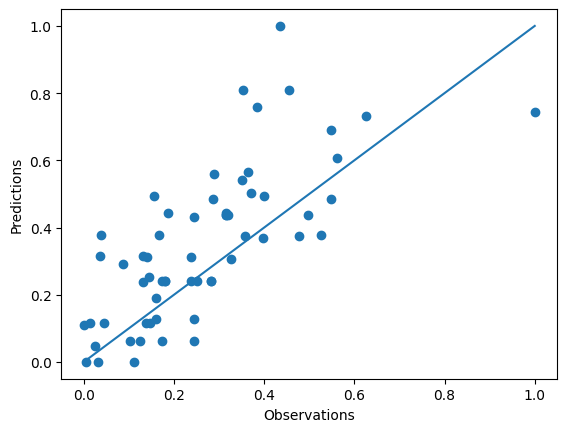

In [163]:
#Plotting the data to see the fit, scaling to find relative fit to observed data
y_test_scaled = (y_test - y_test.min()) / (y_test.max() - y_test.min())
y_pred_scaled = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())
plt.scatter(y_test_scaled, y_pred_scaled)
plt.plot([0, 1], [0, 1])
plt.ylabel("Predictions")
plt.xlabel("Observations")

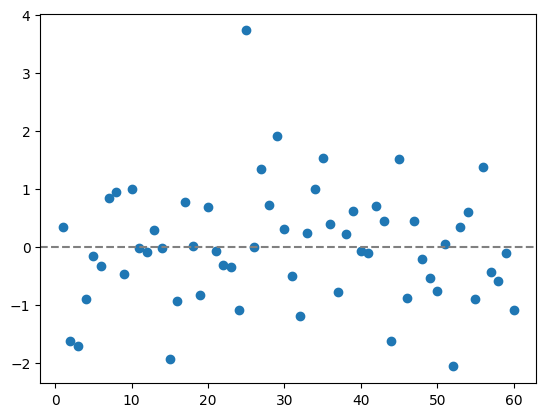

In [164]:
residual_y = (y_test.to_numpy() - y_pred).ravel()
residual_scaled = (residual_y - np.mean(residual_y)) / (np.std(residual_y))
residual_plot = pd.DataFrame({"Iterate": np.arange(1,61), "Residual": residual_scaled})
plt.scatter(residual_plot['Iterate'], residual_plot['Residual'])
plt.axhline(y=0, color='grey', linestyle='--')

Scaling the residuals make it obvious that this model is not a good fit, a lot of residuals are greater than 0.6, while at least 3 lie around 1, 
this makes it clear that the model is far from the predictions, thus not a good fit 

The multivariate linear regression model has been implemented correctly and performs consistently with sklearn’s linear regression. Although the RMSE remains relatively high, the model improves substantially on the baseline, suggesting it captures meaningful structure in the data. However, the remaining error indicates that a linear model may not fully explain the variation in the target.

## Results Summary

| Model | R² | RMSE |
|---|---|---|
| Multivariate regression (scratch) | 0.5148864936016647 | 18035.61883186126|
| Multivariate regression (sklearn) | 0.42363817283363225| 18728.274015231207 |
| Ridge CV | 0.43272580566733965 | 18580.040830531572 |
| Lasso CV | 0.4236381979319982| 18728.273607458643 |

## Key Takeaways

- Implementing linear regression and gradient descent from scratch in NumPy 
  gives a clear picture of how the model converges to the best fit line
- When working with multivariate data, Lasso and Ridge regularisation help 
  identify which predictors are genuinely valuable
- The main limitation encountered was overfitting on a small dataset, 
  reflected in elevated RMSE values

**Next steps:** explore polynomial features and regularisation techniques 
to better handle datasets with limited size and complexity